# KNN

Código desenvolvido na **Aula 1** do curso **Introduction to Data Science with Python**

O código apresenta o desenvolvimento de um modelo a partir do algoritmo K-nearest Neighbors, um classificador de aprendizado supervisionado que usa a proximidade para fazer previsões sobre dados.

> [Harvard CS109x: Introduction to Data Science with Python](https://learning.edx.org/course/course-v1:HarvardX+CS109x+3T2024/home)
> [IBM: O que é KNN](https://www.ibm.com/br-pt/think/topics/knn)

## Baixando e entendendo o Dataset

O dataset apresenta observações da **venda de determinado produto** e do orçamento que foi direcionado à propagandas deste produto em 3 veículos de mídia: TV, Radio e Jornal.

> O Objetivo é prever as vendas de um determinado mês dado o orçamento dedicado às propagandas nos três veículos.

### Informações sobre o dataset obtidas:

- Há 200 observações no dataset
- Há 3 variáveis independentes (x): 'TV', 'Radio' e 'Newspapper'
- Há 1 variável dependente (y): 'Sales'
- Não há dados faltantes em nenhuma das observações

In [136]:

# Download do dataset
import kagglehub

path = kagglehub.dataset_download("ashydv/advertising-dataset")

# Entendendo o dataset 
import pandas as pd

df = pd.read_csv('advertising.csv')

print("HEAD")
print(df.head())
print("INFO")
print(df.info())
print("DESCRIBE")
print(df.describe())
print("SHAPE")
print(df.shape)


HEAD
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
INFO
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
DESCRIBE
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   3

## KNN - Preparo

Para construir um modelo com base no algoritmo kNN, vou selecionar apenas **UMA** variável independente (orçamento de propagandas para a TV), para então tentarmos prever as vendas levando em somente ELA em concideração.

In [138]:
import matplotlib.pyplot as plt

# variável independente (TV)
x = df['TV']

# variável dependente (Sales)
y = df['Sales']

# Para ficar mais fácil de visualizar, peguei uma amostra contendo 10% dos dados.
# Utilizo random_state para garantir que a amostra seja a mesma toda vez que o código for executado.
sample_x = x.sample(frac=.1, random_state=1)
sample_y = y.sample(frac=.1, random_state=1)

# Aqui eu verifico se os índices das amostras são os mesmos.
# Já que uma observação de Sales deve estar relacionada a uma observação de TV.
print("=====")
print("sample_x indexes:", sample_x.index)
print("=====")
print("sample_y indexes:", sample_y.index)
print("=====")


=====
sample_x indexes: Index([ 58,  40,  34, 102, 184, 198,  95,   4,  29, 168, 171,  18,  11,  89,
       110, 118, 159,  35, 136,  59],
      dtype='int64')
=====
sample_y indexes: Index([ 58,  40,  34, 102, 184, 198,  95,   4,  29, 168, 171,  18,  11,  89,
       110, 118, 159,  35, 136,  59],
      dtype='int64')
=====


## Plotando Gráfico TV X Sales

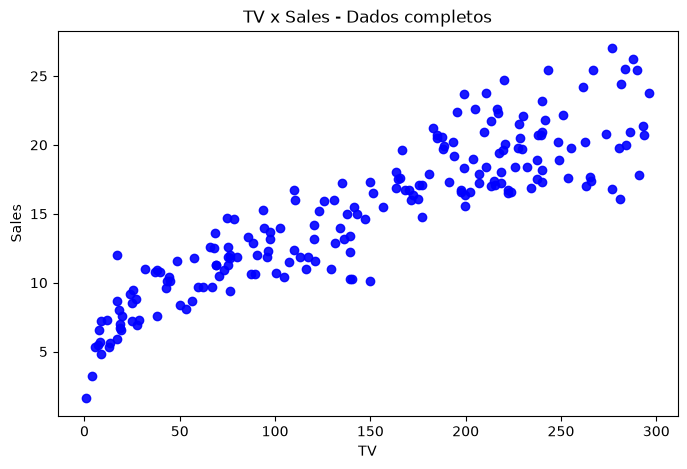

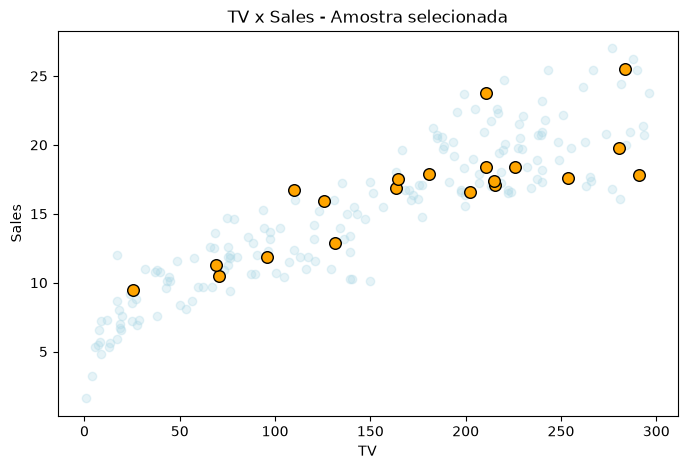

In [142]:
# Gráfico completo
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.9, color='blue')
plt.title('TV x Sales - Dados completos')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

# Novo gráfico apenas com a amostra
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.3, color='lightblue')
plt.scatter(sample_x, sample_y, color='orange', s=70, edgecolor='black')
plt.title('TV x Sales - Amostra selecionada')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

## Código kNN

KNN with k=3
Distances:
 34       5.7
29      19.4
89      19.8
18      20.8
118     35.7
159     41.7
136     64.4
95      73.3
171     74.5
4       90.8
40     112.5
59     120.7
58     120.8
11     124.7
168    125.4
110    135.8
184    163.8
102    190.2
198    193.6
35     200.7
dtype: float64
Indexes of k nearest neighbors:
 Index([34, 29, 89], dtype='int64')
Prediction: 13.033333333333331


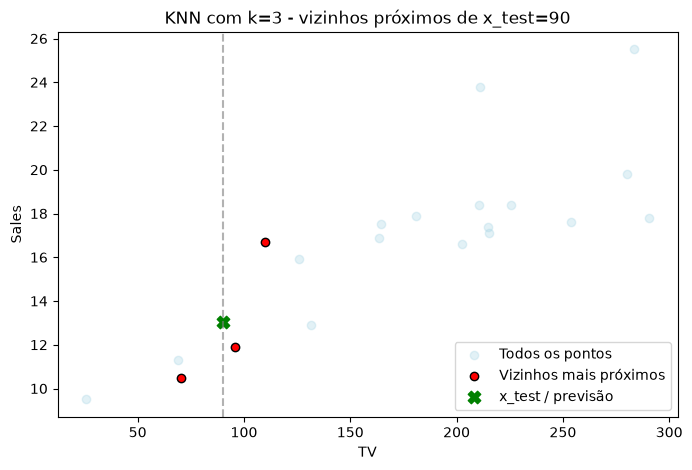

np.float64(13.033333333333331)

In [155]:
def knn(k, X_train, Y_train, x_test, plot: bool = True):

    print(f"KNN with k={k}")
    if (len(X_train) != len(Y_train)):
        raise ValueError("X_train and Y_train must have the same length")
    if (X_train.index != Y_train.index).any():
        raise ValueError("X_train and Y_train must have the same indexes")
    
    # calcula a distância de cada ponto ao valor de teste
    distances = pd.Series([abs(x - x_test) for x in X_train], index=X_train.index)

    distances_sorted = distances.sort_values()
    result_indexes = distances_sorted.index[:k]
    prediction = Y_train.loc[result_indexes].mean()

    print("Distances:\n", distances_sorted)
    print("Indexes of k nearest neighbors:\n", result_indexes)
    print("Prediction:", prediction)

    # visualização do funcionamento do algoritmo
    if plot:
        plt.figure(figsize=(8, 5))
        plt.scatter(X_train, Y_train, alpha=0.35, color='lightblue', label='Todos os pontos')
        plt.scatter(X_train.loc[result_indexes], Y_train.loc[result_indexes],
                    color='red', edgecolor='black', label='Vizinhos mais próximos')
        plt.scatter(x_test, prediction, color='green', marker='X', s=80,
                    label='x_test / previsão')
        plt.axvline(x_test, color='gray', linestyle='--', alpha=0.6)
        plt.title(f'KNN com k={k} - vizinhos próximos de x_test={x_test}')
        plt.xlabel('TV')
        plt.ylabel('Sales')
        plt.legend()
        plt.show()

    return prediction
        
knn(3, sample_x, sample_y, 90)
# plotar

KNN with k=3
Distances:
 136     25.6
18      69.2
29      70.6
34      95.7
89     109.8
118    125.7
159    131.7
95     163.3
171    164.5
4      180.8
40     202.5
59     210.7
58     210.8
11     214.7
168    215.4
110    225.8
184    253.8
102    280.2
198    283.6
35     290.7
dtype: float64
Indexes of k nearest neighbors:
 Index([136, 18, 29], dtype='int64')
Prediction: 10.433333333333334
KNN with k=3
Distances:
 136     24.6
18      68.2
29      69.6
34      94.7
89     108.8
118    124.7
159    130.7
95     162.3
171    163.5
4      179.8
40     201.5
59     209.7
58     209.8
11     213.7
168    214.4
110    224.8
184    252.8
102    279.2
198    282.6
35     289.7
dtype: float64
Indexes of k nearest neighbors:
 Index([136, 18, 29], dtype='int64')
Prediction: 10.433333333333334
KNN with k=3
Distances:
 136     23.6
18      67.2
29      68.6
34      93.7
89     107.8
118    123.7
159    129.7
95     161.3
171    162.5
4      178.8
40     200.5
59     208.7
58     208.8
11    

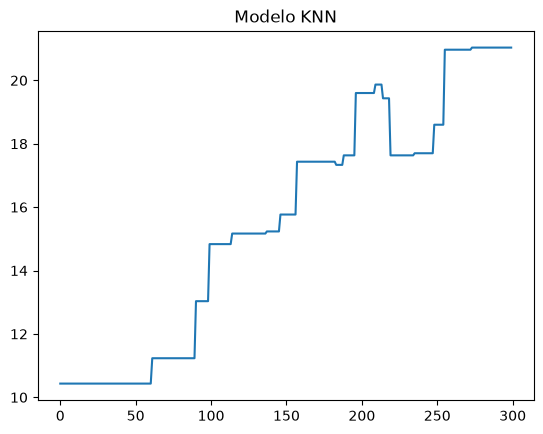

In [159]:
# Criando o modelo KNN com k=3
# Vou utilizar todas as 200 observações
# Vou utilizar = 3

model = pd.Series([knn(3, sample_x, sample_y, x_test, False) for x_test in range(0, 300)])

# Plotar o resultado em um gráfico de linha (tentando achar a linha do modelo)
model.plot(kind='line', title='Modelo KNN')


print(model)